In [1]:
import torch
from torchvision import datasets 
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split, DataLoader, Subset, Dataset
import torchvision.models as models
import numpy as np
import torch.nn as nn
import open_clip

In [2]:
normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


stl10_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean = normalize_mean, std = normalize_std)
    ]
)


STL10_TRAIN = datasets.STL10(root='./data', split = "train", transform=stl10_transform, download=False)
STL10_TEST = datasets.STL10(root='./data', split = "test", transform=stl10_transform, download=False)




In [3]:
import numpy as np
from torch.utils.data import Subset

# Seeded random number generator
rng = np.random.default_rng(6304)

selected_indices = []

# 500 images total / 10 classes = 50 images per class
num_per_class = 50

for i in range(len(STL10_TEST.classes)):

    # Get indices belonging to this class
    class_indices = np.where(STL10_TEST.labels == i)[0]

    # Randomly select 50 without replacement
    sampled_indices = rng.choice(
        class_indices,
        size=num_per_class,
        replace=False
    )

    selected_indices.extend(sampled_indices.tolist())


# Save the selected image identifiers/indices
np.save("selected_test_indices.npy", selected_indices)


# Create the 500-image test subset
STL10_TEST = Subset(
    STL10_TEST,
    selected_indices
)

print(f"Number of selected images: {len(STL10_TEST)}")

Number of selected images: 500


In [4]:
train_size = int(0.8 * len(STL10_TRAIN))
val_size = len(STL10_TRAIN) - train_size

torch.manual_seed(6304)
Train_set, Val_set = random_split(STL10_TRAIN, [train_size, val_size], )

train_loader = DataLoader(Train_set, batch_size = 8, shuffle=True, num_workers=2)
val_loader = DataLoader(Val_set, batch_size = 8, shuffle=False, num_workers=2)

test_loader=DataLoader(STL10_TEST, batch_size=8, shuffle=False, num_workers=2)




In [5]:
from collections import Counter

def class_frequency(loader):
    counts = Counter()

    for images, labels in loader:
        counts.update(labels.tolist())

    return counts

print("Train:", class_frequency(train_loader))
print("Validation:", class_frequency(val_loader))
print("Test", class_frequency(test_loader))


Train: Counter({3: 411, 4: 408, 1: 406, 8: 405, 7: 399, 6: 398, 5: 396, 2: 396, 9: 392, 0: 389})
Validation: Counter({0: 111, 9: 108, 2: 104, 5: 104, 6: 102, 7: 101, 8: 95, 1: 94, 4: 92, 3: 89})
Test Counter({0: 50, 1: 50, 2: 50, 3: 50, 4: 50, 5: 50, 6: 50, 7: 50, 8: 50, 9: 50})


In [6]:
# Classifier Backbones

# ResNet
weights = models.ResNet50_Weights.IMAGENET1K_V2
ResNet50 = models.resnet50(weights=weights)

for param in ResNet50.parameters():
      param.requires_grad = False

ResNet50.fc = nn.Linear(ResNet50.fc.in_features, 10)

# ViT

weights = models.ViT_B_16_Weights.IMAGENET1K_V1
ViT16 = models.vit_b_16(weights=weights)

for param in ViT16.parameters():
      param.requires_grad = False

ViT16.heads.head = nn.Linear(ViT16.heads.head.in_features, 10)

# CLIP Model
class PreTrainedCLIP(nn.Module):
    def __init__(self):
          super().__init__()

          self.backbone, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
          self.backbone.requires_grad_(False)

          self.backbone.eval()

          self.classifier  = nn.Linear(self.backbone.visual.output_dim, 10)

    def train(self, mode=True):
          super().train(mode)
          self.backbone.eval()
          return self

    def forward(self, images):
      with torch.no_grad():
            features = self.backbone.encode_image(images)
      logits = self.classifier(features)
      return logits
          



In [7]:
def train_model_epoch(model, train_loader, val_loader, criterion, optimizer):
    model = model.to(device)


    # =========================
    # Training
    # =========================

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = model(images)

        # Calculate loss
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        train_loss += loss.item()

        # Get predicted classes
        predictions = logits.argmax(dim=1)

        # Number of correct predictions
        train_correct += (
            predictions == labels
        ).sum().item()

        # Number of samples
        train_total += labels.size(0)


    # Average training loss
    train_loss = train_loss / len(train_loader)

    # Training accuracy
    train_accuracy = train_correct / train_total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(images)

            # Calculate loss
            loss = criterion(logits, labels)

            # Accumulate loss
            val_loss += loss.item()

            # Get predicted classes
            predictions = logits.argmax(dim=1)

            # Number of correct predictions
            val_correct += (
                predictions == labels
            ).sum().item()

            # Number of samples
            val_total += labels.size(0)


    # Average validation loss
    val_loss = val_loss / len(val_loader)

    # Validation accuracy
    val_accuracy = val_correct / val_total


    # =========================
    # Results
    # =========================

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    return train_loss, train_accuracy, val_loss, val_accuracy

import copy


def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    # Store metrics
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    # Early stopping variables
    best_val_accuracy = 0.0
    best_model_state = None
    epochs_without_improvement = 0


    for epoch in range(num_epochs):

        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        train_loss, train_accuracy, val_loss, val_accuracy = (
            train_model_epoch(
                model,
                train_loader,
                val_loader,
                criterion,
                optimizer
            )
        )

        # Store metrics
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)


        # =====================================
        # Early Stopping
        # =====================================

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            # Save best model
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            # Reset counter
            epochs_without_improvement = 0

            print(
                f"Validation accuracy improved to "
                f"{best_val_accuracy:.4f}"
            )

        else:

            epochs_without_improvement += 1

            print(
                f"No improvement for "
                f"{epochs_without_improvement}/{patience} epochs"
            )


        # Stop training
        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch {epoch + 1}"
            )

            break


    # =====================================
    # Restore best model
    # =====================================

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(
        f"\nBest validation accuracy: "
        f"{best_val_accuracy:.4f}"
    )

    return model, history

In [8]:
import pandas as pd
from sklearn.metrics import f1_score

def evaluate_classifier(model, loader):
    model = model.to(device)
    model.eval()

    all_labels = []
    all_predictions = []
    all_confidences = []

    for images,labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_confidences.extend(confidences.detach().cpu().numpy())

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)
    all_confidences = np.array(all_confidences)

    top1_accuracy = np.mean(all_predictions == all_labels)
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )
    mean_max_confidence = np.mean(all_confidences)

    return top1_accuracy, macro_f1, mean_max_confidence


In [9]:
def evaluate_classifier_zero_shot(
    model,
    loader,
    class_names,
    tokenizer,
    device
):
    model = model.to(device)
    model.eval()

    # Create prompts using the required template
    prompts = [
        f"a photo of a {class_name}"
        for class_name in class_names
    ]

    text_tokens = tokenizer(prompts).to(device)

    # Encode class prompts
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)

        # L2 normalization
        text_features = text_features / text_features.norm(
            dim=-1,
            keepdim=True
        )

    # ImageNet normalization used by test_loader
    imagenet_mean = torch.tensor(
        normalize_mean,
        device=device
    ).view(1, 3, 1, 1)

    imagenet_std = torch.tensor(
        normalize_std,
        device=device
    ).view(1, 3, 1, 1)

    # CLIP normalization
    clip_mean = torch.tensor(
        model.visual.image_mean,
        device=device
    ).view(1, 3, 1, 1)

    clip_std = torch.tensor(
        model.visual.image_std,
        device=device
    ).view(1, 3, 1, 1)

    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            # Undo ImageNet normalization
            images = images * imagenet_std + imagenet_mean

            # Apply CLIP normalization
            images = (images - clip_mean) / clip_std

            # Encode images
            image_features = model.encode_image(images)

            # L2 normalization
            image_features = image_features / image_features.norm(
                dim=-1,
                keepdim=True
            )

            # Cosine similarity between images and text prompts
            logits = (
                model.logit_scale.exp()
                * image_features
                @ text_features.T
            )

            probabilities = torch.softmax(logits, dim=1)

            confidences, predictions = probabilities.max(dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(
                predictions.cpu().numpy()
            )
            all_confidences.extend(
                confidences.detach().cpu().numpy()
            )

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)
    all_confidences = np.array(all_confidences)

    top1_accuracy = np.mean(
        all_predictions == all_labels
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    mean_max_confidence = np.mean(all_confidences)

    return top1_accuracy, macro_f1, mean_max_confidence

In [10]:
from torchvision.models import resnet50, ResNet50_Weights
# ------------------------------------------------------------
# 1. Train ResNet-50
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Training ResNet-50")
print("=" * 60)

ResNet50_trained, _ = train_model(
    ResNet50,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5
)

resnet_metrics = evaluate_classifier(
    ResNet50_trained,
    test_loader
)


# ------------------------------------------------------------
# 2. Train ViT-B/16
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Training ViT-B/16")
print("=" * 60)

ViT16_trained, _ = train_model(
    ViT16,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5
)

vit_metrics = evaluate_classifier(
    ViT16_trained,
    test_loader
)


# ------------------------------------------------------------
# 3. Train CLIP linear classifier
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Training CLIP ViT-B/32 Linear Classifier")
print("=" * 60)

CLIP_classifier = PreTrainedCLIP()

CLIP_classifier_trained, _ = train_model(
    CLIP_classifier,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5
)

clip_classifier_metrics = evaluate_classifier(
    CLIP_classifier_trained,
    test_loader
)

# ------------------------------------------------------------
# Zero-shot CLIP
# ------------------------------------------------------------

clip_zero_shot, _, clip_preprocess = (
    open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai"
    )
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

class_names = STL10_TRAIN.classes

clip_zero_shot_metrics = evaluate_classifier_zero_shot(
    clip_zero_shot,
    test_loader,
    class_names,
    tokenizer,
    device
)


Training ResNet-50

Epoch 1/50
Train Loss: 0.5831 | Train Acc: 0.8660 | Val Loss: 0.2350 | Val Acc: 0.9650
Validation accuracy improved to 0.9650

Epoch 2/50
Train Loss: 0.2281 | Train Acc: 0.9375 | Val Loss: 0.1496 | Val Acc: 0.9660
Validation accuracy improved to 0.9660

Epoch 3/50
Train Loss: 0.1803 | Train Acc: 0.9493 | Val Loss: 0.1351 | Val Acc: 0.9690
Validation accuracy improved to 0.9690

Epoch 4/50
Train Loss: 0.1515 | Train Acc: 0.9505 | Val Loss: 0.1203 | Val Acc: 0.9670
No improvement for 1/5 epochs

Epoch 5/50
Train Loss: 0.1237 | Train Acc: 0.9627 | Val Loss: 0.1145 | Val Acc: 0.9730
Validation accuracy improved to 0.9730

Epoch 6/50
Train Loss: 0.1149 | Train Acc: 0.9660 | Val Loss: 0.1055 | Val Acc: 0.9700
No improvement for 1/5 epochs

Epoch 7/50
Train Loss: 0.1024 | Train Acc: 0.9683 | Val Loss: 0.1076 | Val Acc: 0.9720
No improvement for 2/5 epochs

Epoch 8/50
Train Loss: 0.0983 | Train Acc: 0.9692 | Val Loss: 0.1094 | Val Acc: 0.9700
No improvement for 3/5 epochs


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.11/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(



Epoch 1/50
Train Loss: 0.4079 | Train Acc: 0.9497 | Val Loss: 0.1182 | Val Acc: 0.9760
Validation accuracy improved to 0.9760

Epoch 2/50
Train Loss: 0.0776 | Train Acc: 0.9828 | Val Loss: 0.0831 | Val Acc: 0.9790
Validation accuracy improved to 0.9790

Epoch 3/50
Train Loss: 0.0535 | Train Acc: 0.9855 | Val Loss: 0.0746 | Val Acc: 0.9810
Validation accuracy improved to 0.9810

Epoch 4/50
Train Loss: 0.0405 | Train Acc: 0.9902 | Val Loss: 0.0687 | Val Acc: 0.9800
No improvement for 1/5 epochs

Epoch 5/50
Train Loss: 0.0332 | Train Acc: 0.9910 | Val Loss: 0.0662 | Val Acc: 0.9800
No improvement for 2/5 epochs

Epoch 6/50
Train Loss: 0.0276 | Train Acc: 0.9935 | Val Loss: 0.0636 | Val Acc: 0.9780
No improvement for 3/5 epochs

Epoch 7/50
Train Loss: 0.0225 | Train Acc: 0.9952 | Val Loss: 0.0653 | Val Acc: 0.9830
Validation accuracy improved to 0.9830

Epoch 8/50
Train Loss: 0.0202 | Train Acc: 0.9952 | Val Loss: 0.0651 | Val Acc: 0.9830
No improvement for 1/5 epochs

Epoch 9/50
Train Lo

/usr/local/lib/python3.11/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [11]:
results = pd.DataFrame(
    [
        ["ResNet-50", *resnet_metrics],
        ["ViT-B/16", *vit_metrics],
        ["CLIP ViT-B/32 (Linear Classifier)",
         *clip_classifier_metrics],
        ["CLIP ViT-B/32 (Zero-Shot)",
         *clip_zero_shot_metrics],
    ],
    columns=[
        "Model",
        "Top-1 Accuracy",
        "Macro-F1",
        "Mean Maximum Confidence"
    ]
)

display(results.round(4))

,Model,Top-1 Accuracy,Macro-F1,Mean Maximum Confidence
0,ResNet-50,0.970,0.9699,0.9460
1,ViT-B/16,0.980,0.9799,0.9814
2,CLIP ViT-B/32 (Linear Classifier),0.980,0.9800,0.9819
3,CLIP ViT-B/32 (Zero-Shot),0.966,0.9655,0.9430


## Class for intervened Dataset

In [12]:
class IntervenedDataset(Dataset):
    def __init__(self, data, transform = None):
        self.data = data
        self.transform = transform

    def __getitem__(self, idx):
        x, label = self.data[idx]

        if self.transform is not None:
            x = self.transform(x)

        return x, label

    def __len__(self):
        return len(self.data)

# Color Bias

In [13]:
import torchvision.transforms.functional as TF

greyscale_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3)
    ]
)


fixed_hue_transform = transforms.Compose([
    transforms.Lambda(lambda img: TF.adjust_hue(img, hue_factor=0.25))
])

GrayScaleDatset = IntervenedDataset(test_loader.dataset, transform=greyscale_transform)
HueTransformDataset = IntervenedDataset(test_loader.dataset, transform = fixed_hue_transform)


greyscale_test_loader=DataLoader(GrayScaleDatset, batch_size=8, shuffle=False, num_workers=2)
hue_test_loader = DataLoader(
    HueTransformDataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)


resnet_metrics_greyscale = evaluate_classifier(
    ResNet50_trained,
    greyscale_test_loader
)

vit_metrics_greyscale = evaluate_classifier(
    ViT16_trained,
    greyscale_test_loader
)

clip_classifier_metrics_greyscale = evaluate_classifier(
    CLIP_classifier_trained,
    greyscale_test_loader
)

clip_zero_shot_metrics_greyscale = evaluate_classifier_zero_shot(
    clip_zero_shot,
    greyscale_test_loader,
    class_names,
    tokenizer,
    device
)

results_greyscale = pd.DataFrame(
    [
        ["ResNet-50", *resnet_metrics_greyscale],
        ["ViT-B/16", *vit_metrics_greyscale],
        ["CLIP ViT-B/32 (Linear Classifier)",
         *clip_classifier_metrics_greyscale],
        ["CLIP ViT-B/32 (Zero-Shot)",
         *clip_zero_shot_metrics_greyscale],
    ],
    columns=[
        "Model",
        "Top-1 Accuracy",
        "Macro-F1",
        "Mean Maximum Confidence"
    ]
)

display(results.round(4))


# ------------------------------------------------------------
# Evaluate ResNet-50
# ------------------------------------------------------------

resnet_metrics_hue = evaluate_classifier(
    ResNet50_trained,
    hue_test_loader
)


# ------------------------------------------------------------
# Evaluate ViT-B/16
# ------------------------------------------------------------

vit_metrics_hue = evaluate_classifier(
    ViT16_trained,
    hue_test_loader
)


# ------------------------------------------------------------
# Evaluate CLIP Linear Classifier
# ------------------------------------------------------------

clip_classifier_metrics_hue = evaluate_classifier(
    CLIP_classifier_trained,
    hue_test_loader
)


# ------------------------------------------------------------
# Evaluate CLIP Zero-Shot
# ------------------------------------------------------------

clip_zero_shot_metrics_hue = evaluate_classifier_zero_shot(
    clip_zero_shot,
    hue_test_loader,
    class_names,
    tokenizer,
    device
)


# ------------------------------------------------------------
# Create results DataFrame
# ------------------------------------------------------------

results_hue = pd.DataFrame(
    [
        ["ResNet-50", *resnet_metrics_hue],
        ["ViT-B/16", *vit_metrics_hue],
        [
            "CLIP ViT-B/32 (Linear Classifier)",
            *clip_classifier_metrics_hue
        ],
        [
            "CLIP ViT-B/32 (Zero-Shot)",
            *clip_zero_shot_metrics_hue
        ],
    ],
    columns=[
        "Model",
        "Top-1 Accuracy",
        "Macro-F1",
        "Mean Maximum Confidence"
    ]
)

display(results_hue.round(4))

,Model,Top-1 Accuracy,Macro-F1,Mean Maximum Confidence
0,ResNet-50,0.970,0.9699,0.9460
1,ViT-B/16,0.980,0.9799,0.9814
2,CLIP ViT-B/32 (Linear Classifier),0.980,0.9800,0.9819
3,CLIP ViT-B/32 (Zero-Shot),0.966,0.9655,0.9430


,Model,Top-1 Accuracy,Macro-F1,Mean Maximum Confidence
0,ResNet-50,0.574,0.5425,0.5847
1,ViT-B/16,0.878,0.8770,0.9228
2,CLIP ViT-B/32 (Linear Classifier),0.894,0.8940,0.8779
3,CLIP ViT-B/32 (Zero-Shot),0.850,0.8459,0.8307


# Shape vs Texture

In [14]:
import torch

# Class pairs
ordered_pairs = [
    (0, 1),
    (2, 3),
    (4, 5),
    (6, 7),
    (8, 9)
]

num_per_pair = 25

# All classes involved
required_classes = set(
    c for pair in ordered_pairs for c in pair
)

# Store 25 images from every class
images_by_class = {
    c: [] for c in required_classes
}

# --------------------------------------------------
# Collect 25 images from each class
# --------------------------------------------------
mean = torch.tensor(normalize_mean).view(3, 1, 1)
std = torch.tensor(normalize_std).view(3, 1, 1)
for images, labels in test_loader:

    for image, label in zip(images, labels):

        label = label.item()

        # IMPORTANT: convert normalized tensor back to [0,1]
        image = image * std + mean
        image = image.clamp(0, 1)

        if (
            label in images_by_class
            and len(images_by_class[label]) < num_per_pair
        ):
            images_by_class[label].append(image)

    # Stop once every class has 25 images
    if all(
        len(images_by_class[c]) >= num_per_pair
        for c in required_classes
    ):
        break


# --------------------------------------------------
# Construct the 25 image pairs for each (a, b)
# --------------------------------------------------
#
# We only need to store (a, b).
# The SAME images will later be used for:
#
#   a -> b
#   b -> a
#
# --------------------------------------------------

image_pairs = {}

for class_a, class_b in ordered_pairs:

    pairs = []

    for i in range(num_per_pair):

        img_a = images_by_class[class_a][i]
        img_b = images_by_class[class_b][i]

        pairs.append((img_a, img_b))

    image_pairs[(class_a, class_b)] = pairs


# Optional verification
for pair, pairs in image_pairs.items():
    print(f"{pair}: {len(pairs)} image pairs")

(0, 1): 25 image pairs
(2, 3): 25 image pairs
(4, 5): 25 image pairs
(6, 7): 25 image pairs
(8, 9): 25 image pairs


In [17]:
import os
import torch
import torch.nn as nn

from net import vgg, decoder
from function import adaptive_instance_normalization
from torchvision.utils import save_image

output_dir = "Stylized Images"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Load pretrained AdaIN weights
# --------------------------------------------------

decoder.load_state_dict(
    torch.load(
        "models/decoder.pth",
        map_location=device,
        weights_only=True
    )
)

vgg.load_state_dict(
    torch.load(
        "models/vgg_normalised.pth",
        map_location=device,
        weights_only=True
    )
)

# AdaIN uses VGG up to relu4_1
vgg = nn.Sequential(*list(vgg.children())[:31])

vgg = vgg.to(device).eval()
decoder = decoder.to(device).eval()


# --------------------------------------------------
# Style transfer
# --------------------------------------------------

def style_transfer(content, style, alpha=1.0):
    assert 0.0 <= alpha <= 1.0

    content_was_3d = (content.dim() == 3)

    if content.dim() == 3:
        content = content.unsqueeze(0)

    if style.dim() == 3:
        style = style.unsqueeze(0)

    # IMPORTANT: move inputs to same device as VGG/decoder
    content = content.to(device)
    style = style.to(device)

    with torch.no_grad():

        # Extract features
        content_feat = vgg(content)
        style_feat = vgg(style)

        # AdaIN
        feat = adaptive_instance_normalization(
            content_feat,
            style_feat
        )

        # Style strength
        feat = (
            alpha * feat
            + (1.0 - alpha) * content_feat
        )

        # Decode
        output = decoder(feat)

    if content_was_3d:
        output = output.squeeze(0)

    return output


# --------------------------------------------------
# Process every pair
# --------------------------------------------------

with torch.no_grad():

    for class_a, class_b in ordered_pairs:

        print(
            f"\nProcessing class pair "
            f"({class_a}, {class_b})"
        )

        pairs = image_pairs[(class_a, class_b)]

        for i, (img_a, img_b) in enumerate(pairs, start=1):

            # ==================================================
            # 1. Save original image from class a
            # ==================================================

            original_filename = f"Image{i}.png"

            original_filepath = os.path.join(
                output_dir,
                original_filename
            )

            save_image(
                img_a.cpu(),
                original_filepath
            )

            print(
                f"Saved: {original_filename}"
            )


            # ==================================================
            # 2. a -> b
            #
            # Content = class a image
            # Texture = class b image
            # ==================================================

            output_ab = style_transfer(
                content=img_a,
                style=img_b,
                alpha=1.0
            )

            filename_ab = (
                f"Image{i}_{class_a}_{class_b}.png"
            )

            filepath_ab = os.path.join(
                output_dir,
                filename_ab
            )

            save_image(
                output_ab.cpu(),
                filepath_ab
            )

            print(
                f"Saved: {filename_ab}"
            )


            # ==================================================
            # 3. b -> a
            #
            # SAME image pair, but reverse roles:
            #
            # Content = class b image
            # Texture = class a image
            # ==================================================

            output_ba = style_transfer(
                content=img_b,
                style=img_a,
                alpha=1.0
            )

            filename_ba = (
                f"Image{i}_{class_b}_{class_a}.png"
            )

            filepath_ba = os.path.join(
                output_dir,
                filename_ba
            )

            save_image(
                output_ba.cpu(),
                filepath_ba
            )

            print(
                f"Saved: {filename_ba}"
            )


Processing class pair (0, 1)
Saved: Image1.png
Saved: Image1_0_1.png
Saved: Image1_1_0.png
Saved: Image2.png
Saved: Image2_0_1.png
Saved: Image2_1_0.png
Saved: Image3.png
Saved: Image3_0_1.png
Saved: Image3_1_0.png
Saved: Image4.png
Saved: Image4_0_1.png
Saved: Image4_1_0.png
Saved: Image5.png
Saved: Image5_0_1.png
Saved: Image5_1_0.png
Saved: Image6.png
Saved: Image6_0_1.png
Saved: Image6_1_0.png
Saved: Image7.png
Saved: Image7_0_1.png
Saved: Image7_1_0.png
Saved: Image8.png
Saved: Image8_0_1.png
Saved: Image8_1_0.png
Saved: Image9.png
Saved: Image9_0_1.png
Saved: Image9_1_0.png
Saved: Image10.png
Saved: Image10_0_1.png
Saved: Image10_1_0.png
Saved: Image11.png
Saved: Image11_0_1.png
Saved: Image11_1_0.png
Saved: Image12.png
Saved: Image12_0_1.png
Saved: Image12_1_0.png
Saved: Image13.png
Saved: Image13_0_1.png
Saved: Image13_1_0.png
Saved: Image14.png
Saved: Image14_0_1.png
Saved: Image14_1_0.png
Saved: Image15.png
Saved: Image15_0_1.png
Saved: Image15_1_0.png
Saved: Image16.png
Sav

In [18]:
import re 

class StylizedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        self.samples = []
        
        pattern = re.compile(
            r"^Image\d+_(\d+)_(\d+)\.png$",
            re.IGNORECASE
        )
        for filename in os.listdir(root_dir):
            match = pattern.match(filename)
            if match is None:
                continue
            content_class = int(match.group(1))
            style_class = int(match.group(2))

            filepath = os.path.join(root_dir, filename)
            self.samples.append((filepath, content_class, style_class))
        self.samples.sort()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, content_class, style_class = self.samples[idx]

        # Load image
        image = Image.open(filepath).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        # Two labels: (a, b)
        labels = torch.tensor(
            [content_class, style_class],
            dtype=torch.long
        )

        return image, labels



transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = normalize_mean, std = normalize_std)
])


dataset = StylizedDataset(
    root_dir="Stylized Images",
    transform=transform
)


stylized_test_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)
    

In [19]:
import torch
import numpy as np
from PIL import Image

def evaluate_classifier_bias(model, loader, device):

    model = model.to(device)
    model.eval()

    n_shape = 0
    n_texture = 0
    n_total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            # labels[:, 0] = content / shape
            # labels[:, 1] = style / texture
            shape_labels = labels[:, 0]
            texture_labels = labels[:, 1]

            logits = model(images)
            predictions = logits.argmax(dim=1)

            # Count shape predictions
            n_shape += (
                predictions == shape_labels
            ).sum().item()

            # Count texture predictions
            n_texture += (
                predictions == texture_labels
            ).sum().item()

            # Total images
            n_total += images.size(0)


    # N_shape + N_texture
    n_shape_texture = n_shape + n_texture


    # Shape Bias (%)
    if n_shape_texture > 0:
        shape_bias = (
            n_shape / n_shape_texture
        ) * 100
    else:
        shape_bias = 0.0


    # Coverage (%)
    if n_total > 0:
        coverage = (
            n_shape_texture / n_total
        ) * 100
    else:
        coverage = 0.0


    return (
        shape_bias,
        coverage,
        n_shape,
        n_texture,
        n_shape_texture,
        n_total
    )

def evaluate_zero_shot_classifier_biased(
    model,
    loader,
    class_names,
    tokenizer,
    device
):

    model = model.to(device)
    model.eval()

    # --------------------------------------------------
    # Text prompts
    # --------------------------------------------------

    prompts = [
        f"a photo of a {class_name}"
        for class_name in class_names
    ]

    text_tokens = tokenizer(prompts).to(device)

    with torch.no_grad():

        text_features = model.encode_text(text_tokens)

        text_features = (
            text_features
            / text_features.norm(
                dim=-1,
                keepdim=True
            )
        )


    # --------------------------------------------------
    # ImageNet normalization
    # --------------------------------------------------

    imagenet_mean = torch.tensor(
        normalize_mean,
        device=device
    ).view(1, 3, 1, 1)

    imagenet_std = torch.tensor(
        normalize_std,
        device=device
    ).view(1, 3, 1, 1)


    # --------------------------------------------------
    # CLIP normalization
    # --------------------------------------------------

    clip_mean = torch.tensor(
        model.visual.image_mean,
        device=device
    ).view(1, 3, 1, 1)

    clip_std = torch.tensor(
        model.visual.image_std,
        device=device
    ).view(1, 3, 1, 1)


    # --------------------------------------------------
    # Counters
    # --------------------------------------------------

    n_shape = 0
    n_texture = 0
    n_total = 0


    # --------------------------------------------------
    # Evaluation
    # --------------------------------------------------

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            shape_labels = labels[:, 0]
            texture_labels = labels[:, 1]


            # Undo ImageNet normalization
            images = (
                images * imagenet_std
                + imagenet_mean
            )

            # Apply CLIP normalization
            images = (
                images - clip_mean
            ) / clip_std


            # Encode images
            image_features = model.encode_image(images)

            image_features = (
                image_features
                / image_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )


            # Image-text similarity
            logits = (
                model.logit_scale.exp()
                * image_features
                @ text_features.T
            )

            predictions = logits.argmax(dim=1)


            # Count predictions
            n_shape += (
                predictions == shape_labels
            ).sum().item()

            n_texture += (
                predictions == texture_labels
            ).sum().item()

            n_total += images.size(0)


    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------

    n_shape_texture = n_shape + n_texture

    if n_shape_texture > 0:
        shape_bias = (
            n_shape / n_shape_texture
        ) * 100
    else:
        shape_bias = 0.0


    if n_total > 0:
        coverage = (
            n_shape_texture / n_total
        ) * 100
    else:
        coverage = 0.0


    return (
        shape_bias,
        coverage,
        n_shape,
        n_texture,
        n_shape_texture,
        n_total
    )

In [20]:
# ------------------------------------------------------------
# Evaluate Shape/Texture Bias on Stylized Dataset
# ------------------------------------------------------------

import pandas as pd


# ------------------------------------------------------------
# Evaluate ResNet-50
# ------------------------------------------------------------

resnet_bias_metrics = evaluate_classifier_bias(
    ResNet50_trained,
    stylized_test_loader,
    device
)


# ------------------------------------------------------------
# Evaluate ViT-B/16
# ------------------------------------------------------------

vit_bias_metrics = evaluate_classifier_bias(
    ViT16_trained,
    stylized_test_loader,
    device
)


# ------------------------------------------------------------
# Evaluate CLIP Linear Classifier
# ------------------------------------------------------------

clip_classifier_bias_metrics = evaluate_classifier_bias(
    CLIP_classifier_trained,
    stylized_test_loader,
    device
)


# ------------------------------------------------------------
# Evaluate CLIP Zero-Shot
# ------------------------------------------------------------

clip_zero_shot_bias_metrics = evaluate_zero_shot_classifier_biased(
    clip_zero_shot,
    stylized_test_loader,
    class_names,
    tokenizer,
    device
)


# ------------------------------------------------------------
# Create Results DataFrame
# ------------------------------------------------------------

results_bias = pd.DataFrame(
    [
        [
            "ResNet-50",
            *resnet_bias_metrics
        ],
        [
            "ViT-B/16",
            *vit_bias_metrics
        ],
        [
            "CLIP ViT-B/32 (Linear Classifier)",
            *clip_classifier_bias_metrics
        ],
        [
            "CLIP ViT-B/32 (Zero-Shot)",
            *clip_zero_shot_bias_metrics
        ],
    ],
    columns=[
        "Model",
        "Shape Bias (%)",
        "Coverage (%)",
        "N_shape",
        "N_texture",
        "N_shape + N_texture",
        "N_total"
    ]
)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

display(results_bias.round(4))

,Model,Shape Bias (%),Coverage (%),N_shape,N_texture,N_shape + N_texture,N_total
0,ResNet-50,61.1940,56.5401,82,52,134,237
1,ViT-B/16,82.1622,78.0591,152,33,185,237
2,CLIP ViT-B/32 (Linear Classifier),86.8421,80.1688,165,25,190,237
3,CLIP ViT-B/32 (Zero-Shot),86.9565,77.6371,160,24,184,237


# Translation

In [21]:
import torch.nn.functional as F

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset


class TranslatedDataset(Dataset):

    def __init__(self, data, shift, transform=None):
        self.data = data
        self.transform = transform
        self.shift = shift

    def __getitem__(self, idx):
        x, label = self.data[idx]
    
        if self.transform is not None:
            x = self.transform(x)
    
        # No translation
        if self.shift == 0:
            return x.unsqueeze(0), label  # [1, C, H, W]
    
        d = self.shift
    
        # x has shape [C, H, W]
        _, H, W = x.shape
    
        # Reflection padding
        # Order: (left, right, top, bottom)
        x_pad = F.pad(
            x,
            (d, d, d, d),
            mode="reflect"
        )
    
        # North: content moves upward
        north = x_pad[
            :,
            2*d : 2*d + H,
            d : d + W
        ]
    
        # South: content moves downward
        south = x_pad[
            :,
            0 : H,
            d : d + W
        ]
    
        # East: content moves right
        east = x_pad[
            :,
            d : d + H,
            0 : W
        ]
    
        # West: content moves left
        west = x_pad[
            :,
            d : d + H,
            2*d : 2*d + W
        ]
    
        # [5, C, H, W]
        # Order: original, north, south, east, west
        images = torch.stack(
            [x, north, south, east, west],
            dim=0
        )
    
        return images, label

    def __len__(self):
        return len(self.data)

In [22]:
import numpy as np
import torch
from sklearn.metrics import f1_score


def evaluate_classifier_translated_dataset(model, loader, device):
    model = model.to(device)
    model.eval()

    # Predictions for:
    # 0 = original
    # 1 = north
    # 2 = south
    # 3 = east
    # 4 = west
    all_labels = []
    all_predictions = [[] for _ in range(5)]
    all_confidences = [[] for _ in range(5)]

    num_views = None

    with torch.no_grad():
        for images, labels in loader:

            # images: [B, V, C, H, W]
            # V = 1 for shift=0
            # V = 5 otherwise
            images = images.to(device)
            labels = labels.to(device)

            B, V, C, H, W = images.shape
            num_views = V

            # Process all views in one forward pass
            images_flat = images.view(B * V, C, H, W)

            logits = model(images_flat)
            probabilities = torch.softmax(logits, dim=1)

            confidences, predictions = probabilities.max(dim=1)

            # Back to [B, V]
            predictions = predictions.view(B, V)
            confidences = confidences.view(B, V)

            all_labels.extend(labels.cpu().numpy())

            for v in range(V):
                all_predictions[v].extend(
                    predictions[:, v].cpu().numpy()
                )

                all_confidences[v].extend(
                    confidences[:, v].cpu().numpy()
                )

    all_labels = np.array(all_labels)

    predictions = [
        np.array(all_predictions[v])
        for v in range(num_views)
    ]

    confidences = [
        np.array(all_confidences[v])
        for v in range(num_views)
    ]

    # ---------------------------------------------------------
    # shift = 0
    # Only original image exists
    # ---------------------------------------------------------
    if num_views == 1:

        top1_accuracy = np.mean(
            predictions[0] == all_labels
        )

        macro_f1 = f1_score(
            all_labels,
            predictions[0],
            average="macro"
        )

        mean_max_confidence = np.mean(
            confidences[0]
        )

        # T_0(x) = x
        consistency = 1.0

        return (
            top1_accuracy,
            macro_f1,
            mean_max_confidence,
            consistency
        )

    # ---------------------------------------------------------
    # shift > 0
    #
    # predictions[0] = original
    # predictions[1] = north
    # predictions[2] = south
    # predictions[3] = east
    # predictions[4] = west
    # ---------------------------------------------------------

    accuracies = []
    f1_scores = []
    mean_confidences = []
    consistencies = []

    original_predictions = predictions[0]

    for v in range(1, 5):

        # Accuracy for this direction
        accuracy = np.mean(
            predictions[v] == all_labels
        )

        # Macro F1 for this direction
        f1 = f1_score(
            all_labels,
            predictions[v],
            average="macro"
        )

        # Confidence for this direction
        confidence = np.mean(
            confidences[v]
        )

        # Consistency with original prediction
        consistency = np.mean(
            predictions[v] == original_predictions
        )

        accuracies.append(accuracy)
        f1_scores.append(f1)
        mean_confidences.append(confidence)
        consistencies.append(consistency)

    # Average over north/south/east/west
    top1_accuracy = np.mean(accuracies)
    macro_f1 = np.mean(f1_scores)
    mean_max_confidence = np.mean(mean_confidences)

    # Average consistency over all four translations
    consistency = np.mean(consistencies)

    return (
        top1_accuracy,
        macro_f1,
        mean_max_confidence,
        consistency
    )


def evaluate_classifier_zero_shot_translated_dataset(
    model,
    loader,
    class_names,
    tokenizer,
    device
):
    model = model.to(device)
    model.eval()

    # ---------------------------------------------------------
    # Text features
    # ---------------------------------------------------------

    prompts = [
        f"a photo of a {class_name}"
        for class_name in class_names
    ]

    text_tokens = tokenizer(prompts).to(device)

    with torch.no_grad():

        text_features = model.encode_text(text_tokens)

        text_features = text_features / text_features.norm(
            dim=-1,
            keepdim=True
        )

    # ---------------------------------------------------------
    # Normalization
    # ---------------------------------------------------------

    imagenet_mean = torch.tensor(
        normalize_mean,
        device=device
    ).view(1, 3, 1, 1)

    imagenet_std = torch.tensor(
        normalize_std,
        device=device
    ).view(1, 3, 1, 1)

    clip_mean = torch.tensor(
        model.visual.image_mean,
        device=device
    ).view(1, 3, 1, 1)

    clip_std = torch.tensor(
        model.visual.image_std,
        device=device
    ).view(1, 3, 1, 1)

    # ---------------------------------------------------------
    # Storage
    # ---------------------------------------------------------

    all_labels = []
    all_predictions = [[] for _ in range(5)]
    all_confidences = [[] for _ in range(5)]

    num_views = None

    # ---------------------------------------------------------
    # Evaluation
    # ---------------------------------------------------------

    with torch.no_grad():

        for images, labels in loader:

            # images: [B, V, C, H, W]
            images = images.to(device)

            B, V, C, H, W = images.shape
            num_views = V

            # Flatten views
            images = images.view(
                B * V,
                C,
                H,
                W
            )

            # Undo ImageNet normalization
            images = (
                images * imagenet_std
                + imagenet_mean
            )

            # Apply CLIP normalization
            images = (
                images - clip_mean
            ) / clip_std

            # Encode images
            image_features = model.encode_image(
                images
            )

            # L2 normalize
            image_features = (
                image_features
                / image_features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            # Cosine similarity
            logits = (
                model.logit_scale.exp()
                * image_features
                @ text_features.T
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            confidences, predictions = (
                probabilities.max(dim=1)
            )

            # [B * V] -> [B, V]
            predictions = predictions.view(B, V)
            confidences = confidences.view(B, V)

            all_labels.extend(
                labels.cpu().numpy()
            )

            for v in range(V):

                all_predictions[v].extend(
                    predictions[:, v].cpu().numpy()
                )

                all_confidences[v].extend(
                    confidences[:, v].cpu().numpy()
                )

    # ---------------------------------------------------------
    # Convert to numpy
    # ---------------------------------------------------------

    all_labels = np.array(all_labels)

    predictions = [
        np.array(all_predictions[v])
        for v in range(num_views)
    ]

    confidences = [
        np.array(all_confidences[v])
        for v in range(num_views)
    ]

    # ---------------------------------------------------------
    # shift = 0
    # ---------------------------------------------------------

    if num_views == 1:

        top1_accuracy = np.mean(
            predictions[0] == all_labels
        )

        macro_f1 = f1_score(
            all_labels,
            predictions[0],
            average="macro"
        )

        mean_max_confidence = np.mean(
            confidences[0]
        )

        consistency = 1.0

        return (
            top1_accuracy,
            macro_f1,
            mean_max_confidence,
            consistency
        )

    # ---------------------------------------------------------
    # shift > 0
    # ---------------------------------------------------------

    accuracies = []
    f1_scores = []
    mean_confidences = []
    consistencies = []

    original_predictions = predictions[0]

    # Views 1--4 are N/S/E/W
    for v in range(1, 5):

        accuracy = np.mean(
            predictions[v] == all_labels
        )

        f1 = f1_score(
            all_labels,
            predictions[v],
            average="macro"
        )

        confidence = np.mean(
            confidences[v]
        )

        # Compare prediction on translated image
        # against prediction on original image
        consistency = np.mean(
            predictions[v] == original_predictions
        )

        accuracies.append(accuracy)
        f1_scores.append(f1)
        mean_confidences.append(confidence)
        consistencies.append(consistency)

    # ---------------------------------------------------------
    # Average across four directions
    # ---------------------------------------------------------

    top1_accuracy = np.mean(accuracies)
    macro_f1 = np.mean(f1_scores)
    mean_max_confidence = np.mean(
        mean_confidences
    )

    consistency = np.mean(consistencies)

    return (
        top1_accuracy,
        macro_f1,
        mean_max_confidence,
        consistency
    )

In [23]:
from torch.utils.data import DataLoader
import pandas as pd


# ------------------------------------------------------------
# Translation shifts
# ------------------------------------------------------------

shift_values = [0, 8, 16, 32]

results = []


# ------------------------------------------------------------
# Evaluate all models at each shift
# ------------------------------------------------------------

for shift in shift_values:

    # --------------------------------------------------------
    # Create translated dataset
    # --------------------------------------------------------

    translated_dataset = TranslatedDataset(
        data=test_loader.dataset,
        shift=shift,
        transform=None
    )

    translated_loader = DataLoader(
        translated_dataset,
        batch_size=8,
        shuffle=False
    )


    # --------------------------------------------------------
    # ResNet-50
    # --------------------------------------------------------

    resnet_metrics = evaluate_classifier_translated_dataset(
        ResNet50_trained,
        translated_loader,
        device
    )

    results.append([
        "ResNet-50",
        shift,
        *resnet_metrics
    ])


    # --------------------------------------------------------
    # ViT-B/16
    # --------------------------------------------------------

    vit_metrics = evaluate_classifier_translated_dataset(
        ViT16_trained,
        translated_loader,
        device
    )

    results.append([
        "ViT-B/16",
        shift,
        *vit_metrics
    ])


    # --------------------------------------------------------
    # CLIP Linear Classifier
    # --------------------------------------------------------

    clip_classifier_metrics = evaluate_classifier_translated_dataset(
        CLIP_classifier_trained,
        translated_loader,
        device
    )

    results.append([
        "CLIP ViT-B/32 (Linear Classifier)",
        shift,
        *clip_classifier_metrics
    ])


    # --------------------------------------------------------
    # CLIP Zero-Shot
    # --------------------------------------------------------

    clip_zero_shot_metrics = evaluate_classifier_zero_shot_translated_dataset(
        clip_zero_shot,
        translated_loader,
        class_names,
        tokenizer,
        device
    )

    results.append([
        "CLIP ViT-B/32 (Zero-Shot)",
        shift,
        *clip_zero_shot_metrics
    ])


# ------------------------------------------------------------
# Create Results DataFrame
# ------------------------------------------------------------

results_translation = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Shift",
        "Accuracy",
        "Macro F1",
        "Mean Confidence",
        "Consistency"
    ]
)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

display(results_translation.round(4))

,Model,Shift,Accuracy,Macro F1,Mean Confidence,Consistency
0,ResNet-50,0,0.9700,0.9699,0.9460,1.0000
1,ViT-B/16,0,0.9800,0.9799,0.9814,1.0000
2,CLIP ViT-B/32 (Linear Classifier),0,0.9800,0.9800,0.9819,1.0000
3,CLIP ViT-B/32 (Zero-Shot),0,0.9660,0.9655,0.9430,1.0000
4,ResNet-50,8,0.9710,0.9709,0.9408,0.9830
5,ViT-B/16,8,0.9800,0.9800,0.9811,0.9840
6,CLIP ViT-B/32 (Linear Classifier),8,0.9780,0.9780,0.9781,0.9875
7,CLIP ViT-B/32 (Zero-Shot),8,0.9680,0.9674,0.9405,0.9790
8,ResNet-50,16,0.9695,0.9695,0.9387,0.9845
9,ViT-B/16,16,0.9765,0.9765,0.9806,0.9850


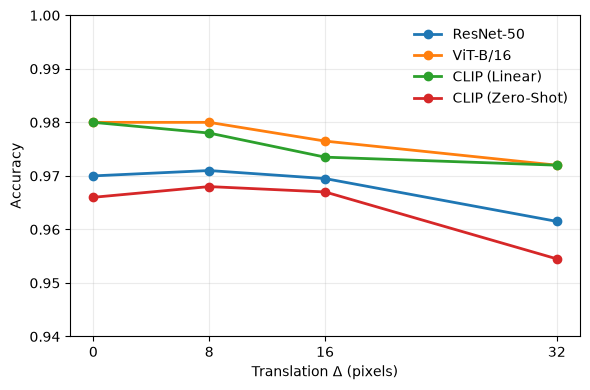

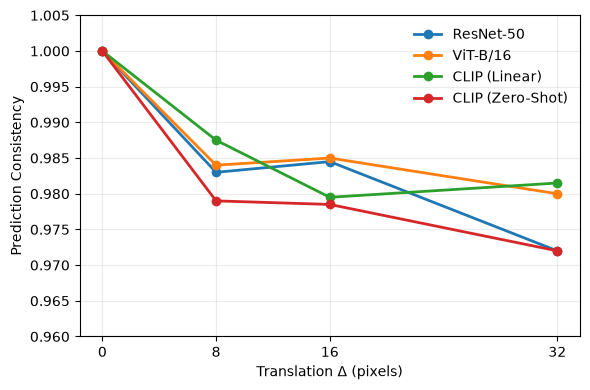

In [38]:
import matplotlib.pyplot as plt

name_map = {
    "ResNet-50": "ResNet-50",
    "ViT-B/16": "ViT-B/16",
    "CLIP ViT-B/32 (Linear Classifier)": "CLIP (Linear)",
    "CLIP ViT-B/32 (Zero-Shot)": "CLIP (Zero-Shot)"
}

colors = {
    "ResNet-50": "tab:blue",
    "ViT-B/16": "tab:orange",
    "CLIP (Linear)": "tab:green",
    "CLIP (Zero-Shot)": "tab:red"
}

plot_df = results_translation.copy()
plot_df["Model"] = plot_df["Model"].replace(name_map)


# ============================================================
# Figure 1: Accuracy vs Translation
# ============================================================

plt.figure(figsize=(6, 4))

for model, group in plot_df.groupby("Model", sort=False):
    plt.plot(
        group["Shift"],
        group["Accuracy"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model
    )

plt.xlabel(r"Translation $\Delta$ (pixels)")
plt.ylabel("Accuracy")
plt.xticks([0, 8, 16, 32])
plt.ylim(0.94, 1.00)
plt.grid(True, alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("translation_accuracy.png", bbox_inches="tight")
plt.show()


# ============================================================
# Figure 2: Prediction Consistency vs Translation
# ============================================================

plt.figure(figsize=(6, 4))

for model, group in plot_df.groupby("Model", sort=False):
    plt.plot(
        group["Shift"],
        group["Consistency"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model
    )

plt.xlabel(r"Translation $\Delta$ (pixels)")
plt.ylabel("Prediction Consistency")
plt.xticks([0, 8, 16, 32])
plt.ylim(0.96, 1.005)
plt.grid(True, alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("translation_consistency.png", bbox_inches="tight")
plt.show()

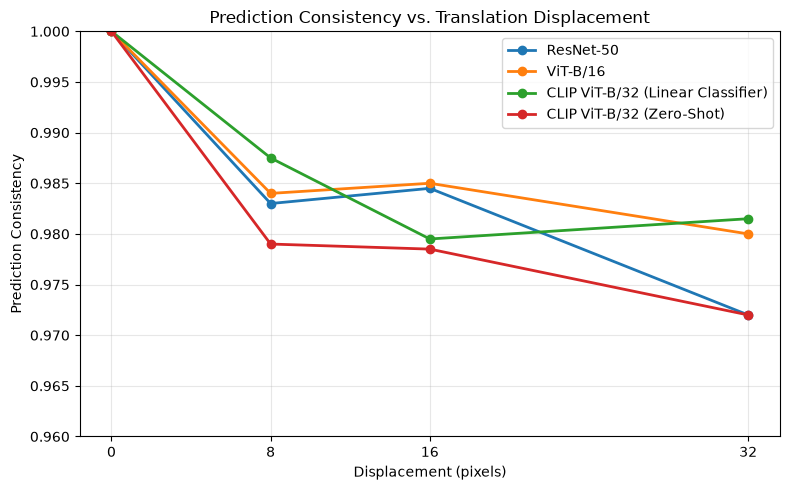

In [24]:
import matplotlib.pyplot as plt



# ------------------------------------------------------------
# Plot Prediction Consistency vs Displacement
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for model_name in results_translation["Model"].unique():

    model_results = results_translation[
        results_translation["Model"] == model_name
    ].sort_values("Shift")

    plt.plot(
        model_results["Shift"],
        model_results["Consistency"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Displacement (pixels)")
plt.ylabel("Prediction Consistency")
plt.title("Prediction Consistency vs. Translation Displacement")

plt.xticks([0, 8, 16, 32])
plt.ylim(0.96, 1)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Patch Structure

In [25]:
import torch
from torch.utils.data import Dataset


class PatchDataset(Dataset):

    def __init__(self, data, transform=None, seed=6304):
        self.data = data
        self.transform = transform
        self.seed = seed

    def __getitem__(self, idx):

        x, label = self.data[idx]

        if self.transform is not None:
            x = self.transform(x)

        # x: [C, H, W]
        C, H, W = x.shape

        grid_size = 4

        if H % grid_size != 0 or W % grid_size != 0:
            raise ValueError(
                f"Image size ({H}, {W}) must be divisible by 4."
            )

        patch_h = H // grid_size
        patch_w = W // grid_size

        # -----------------------------------------------------
        # Split into 4 x 4 = 16 patches
        # -----------------------------------------------------

        # [C, H, W]
        # -> [4, 4, C, patch_h, patch_w]
        patches = (
            x.reshape(
                C,
                grid_size,
                patch_h,
                grid_size,
                patch_w
            )
            .permute(1, 3, 0, 2, 4)
            .contiguous()
        )

        # -> [16, C, patch_h, patch_w]
        patches = patches.reshape(
            grid_size * grid_size,
            C,
            patch_h,
            patch_w
        )

        # -----------------------------------------------------
        # Deterministic permutation for this image
        # -----------------------------------------------------

        generator = torch.Generator()
        generator.manual_seed(self.seed + idx)

        permutation = torch.randperm(
            grid_size * grid_size,
            generator=generator
        )

        # Ensure non-identity permutation
        identity = torch.arange(
            grid_size * grid_size
        )

        if torch.equal(permutation, identity):
            permutation = torch.roll(
                permutation,
                shifts=1
            )

        # -----------------------------------------------------
        # Shuffle patches
        # -----------------------------------------------------

        patches = patches[permutation]

        # -----------------------------------------------------
        # Reconstruct image
        # -----------------------------------------------------

        # [16, C, patch_h, patch_w]
        # -> [4, 4, C, patch_h, patch_w]
        patches = patches.reshape(
            grid_size,
            grid_size,
            C,
            patch_h,
            patch_w
        )

        # -> [C, 4, patch_h, 4, patch_w]
        patches = patches.permute(
            2, 0, 3, 1, 4
        ).contiguous()

        # -> [C, H, W]
        x_permuted = patches.reshape(
            C,
            H,
            W
        )

        return x_permuted, label

    def __len__(self):
        return len(self.data)

In [26]:
from torch.utils.data import DataLoader
import pandas as pd


# ------------------------------------------------------------
# Create Patch-Permuted Dataset
# ------------------------------------------------------------

patch_dataset = PatchDataset(
    test_loader.dataset,
    seed=6304
)

patch_test_loader = DataLoader(
    patch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)


# ------------------------------------------------------------
# Evaluate ResNet-50
# ------------------------------------------------------------

resnet_metrics_patch = evaluate_classifier(
    ResNet50_trained,
    patch_test_loader
)


# ------------------------------------------------------------
# Evaluate ViT-B/16
# ------------------------------------------------------------

vit_metrics_patch = evaluate_classifier(
    ViT16_trained,
    patch_test_loader
)


# ------------------------------------------------------------
# Evaluate CLIP Linear Classifier
# ------------------------------------------------------------

clip_classifier_metrics_patch = evaluate_classifier(
    CLIP_classifier_trained,
    patch_test_loader
)


# ------------------------------------------------------------
# Evaluate CLIP Zero-Shot
# ------------------------------------------------------------

clip_zero_shot_metrics_patch = evaluate_classifier_zero_shot(
    clip_zero_shot,
    patch_test_loader,
    class_names,
    tokenizer,
    device
)


# ------------------------------------------------------------
# Create Results DataFrame
# ------------------------------------------------------------

results_patch = pd.DataFrame(
    [
        [
            "ResNet-50",
            *resnet_metrics_patch
        ],
        [
            "ViT-B/16",
            *vit_metrics_patch
        ],
        [
            "CLIP ViT-B/32 (Linear Classifier)",
            *clip_classifier_metrics_patch
        ],
        [
            "CLIP ViT-B/32 (Zero-Shot)",
            *clip_zero_shot_metrics_patch
        ],
    ],
    columns=[
        "Model",
        "Top-1 Accuracy",
        "Macro-F1",
        "Mean Maximum Confidence"
    ]
)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

display(results_patch.round(4))

,Model,Top-1 Accuracy,Macro-F1,Mean Maximum Confidence
0,ResNet-50,0.886,0.8854,0.8825
1,ViT-B/16,0.906,0.9051,0.9351
2,CLIP ViT-B/32 (Linear Classifier),0.784,0.7846,0.8008
3,CLIP ViT-B/32 (Zero-Shot),0.792,0.7902,0.7618


In [27]:
import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE

REP_SEED = 6304
TSNE_PERPLEXITY = 30
TSNE_N_ITER = 1000
VIS_PER_CLASS = 10
TRANSLATION_SHIFT = 32

np.random.seed(REP_SEED)
torch.manual_seed(REP_SEED)

print("=" * 70)
print("REPRESENTATION ANALYSIS SETTINGS")
print("=" * 70)
print(f"Random seed             : {REP_SEED}")
print(f"Visualization subset    : {VIS_PER_CLASS} images/class")
print(f"t-SNE perplexity        : {TSNE_PERPLEXITY}")
print(f"t-SNE iterations        : {TSNE_N_ITER}")
print(f"Translation displacement: {TRANSLATION_SHIFT} px")
print("Translation stability   : average over north/south/east/west")
print("Projection rule         : one joint clean + transformed t-SNE fit per backbone")

REPRESENTATION ANALYSIS SETTINGS
Random seed             : 6304
Visualization subset    : 10 images/class
t-SNE perplexity        : 30
t-SNE iterations        : 1000
Translation displacement: 32 px
Translation stability   : average over north/south/east/west
Projection rule         : one joint clean + transformed t-SNE fit per backbone


In [28]:
def extract_resnet_features(model, images):
    x = model.conv1(images)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)

    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)

    x = model.avgpool(x)
    return torch.flatten(x, 1)


def extract_vit_features(model, images):
    x = model._process_input(images)
    batch_class_token = model.class_token.expand(x.shape[0], -1, -1)
    x = torch.cat([batch_class_token, x], dim=1)
    x = model.encoder(x)

    return x[:, 0]


def imagenet_to_clip(images, clip_model):
    imagenet_mean = torch.tensor(
        normalize_mean,
        device=images.device,
        dtype=images.dtype
    ).view(1, 3, 1, 1)

    imagenet_std = torch.tensor(
        normalize_std,
        device=images.device,
        dtype=images.dtype
    ).view(1, 3, 1, 1)

    clip_mean = torch.tensor(
        clip_model.visual.image_mean,
        device=images.device,
        dtype=images.dtype
    ).view(1, 3, 1, 1)

    clip_std = torch.tensor(
        clip_model.visual.image_std,
        device=images.device,
        dtype=images.dtype
    ).view(1, 3, 1, 1)

    images = images * imagenet_std + imagenet_mean
    return (images - clip_mean) / clip_std


def extract_clip_features(model, images):
    images = imagenet_to_clip(images, model)
    return model.encode_image(images)


backbones = {
    "ResNet-50": ResNet50_trained,
    "ViT-B/16": ViT16_trained,
    "CLIP ViT-B/32": clip_zero_shot,
}


def extract_features(model_name, model, images):
    if model_name == "ResNet-50":
        return extract_resnet_features(model, images)

    elif model_name == "ViT-B/16":
        return extract_vit_features(model, images)

    elif model_name == "CLIP ViT-B/32":
        return extract_clip_features(model, images)

    else:
        raise ValueError(f"Unknown backbone: {model_name}")

In [29]:
def collect_features(model_name, model, loader):
    model = model.to(device)
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            features = extract_features(
                model_name,
                model,
                images
            )

            all_features.append(
                features.detach().float().cpu()
            )

            all_labels.append(
                labels.detach().cpu()
            )

    return torch.cat(all_features), torch.cat(all_labels)


def cosine_stability(clean_features, transformed_features):
    if clean_features.shape != transformed_features.shape:
        raise ValueError(
            f"Feature shapes do not match: "
            f"{clean_features.shape} vs {transformed_features.shape}"
        )

    similarities = F.cosine_similarity(
        clean_features.float(),
        transformed_features.float(),
        dim=1
    )

    return similarities.mean().item()

In [30]:
clean_dataset = test_loader.dataset

representation_clean_loader = DataLoader(
    clean_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

representation_gray_dataset = IntervenedDataset(
    clean_dataset,
    transform=greyscale_transform
)

representation_gray_loader = DataLoader(
    representation_gray_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

representation_patch_dataset = PatchDataset(
    clean_dataset,
    seed=REP_SEED
)

representation_patch_loader = DataLoader(
    representation_patch_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

representation_translation_dataset = TranslatedDataset(
    clean_dataset,
    shift=TRANSLATION_SHIFT,
    transform=None
)

representation_translation_loader = DataLoader(
    representation_translation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)


def collect_translation_features(model_name, model, loader):
    model = model.to(device)
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            B, V, C, H, W = images.shape
            flat_images = images.reshape(B * V, C, H, W)

            features = extract_features(
                model_name,
                model,
                flat_images
            ).reshape(B, V, -1)

            all_features.append(
                features.detach().float().cpu()
            )

            all_labels.append(labels.cpu())

    return torch.cat(all_features), torch.cat(all_labels)

In [31]:
def build_cue_conflict_pairs():
    clean_images = []
    stylized_images = []
    labels = []

    pattern = re.compile(
        r"^Image(\d+)_(\d+)_(\d+)\.png$",
        re.IGNORECASE
    )

    cue_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=normalize_mean,
            std=normalize_std
        )
    ])

    filenames = sorted(os.listdir("Stylized Images"))

    for filename in filenames:
        match = pattern.match(filename)

        if match is None:
            continue

        image_number = int(match.group(1))
        content_class = int(match.group(2))
        style_class = int(match.group(3))

        if (content_class, style_class) in image_pairs:
            pair_key = (content_class, style_class)
            reverse = False

        elif (style_class, content_class) in image_pairs:
            pair_key = (style_class, content_class)
            reverse = True

        else:
            continue

        pair_index = image_number - 1
        img_a, img_b = image_pairs[pair_key][pair_index]

        clean_img = img_b if reverse else img_a

        mean = torch.tensor(normalize_mean).view(3, 1, 1)
        std = torch.tensor(normalize_std).view(3, 1, 1)

        clean_img = (clean_img - mean) / std

        filepath = os.path.join(
            "Stylized Images",
            filename
        )

        stylized_img = Image.open(
            filepath
        ).convert("RGB")

        stylized_img = cue_transform(stylized_img)

        clean_images.append(clean_img)
        stylized_images.append(stylized_img)
        labels.append(content_class)

    return (
        torch.stack(clean_images),
        torch.stack(stylized_images),
        torch.tensor(labels, dtype=torch.long)
    )


cue_clean_images, cue_stylized_images, cue_labels = (
    build_cue_conflict_pairs()
)

print(f"Cue-conflict pairs found: {len(cue_labels)}")


def collect_tensor_features(
    model_name,
    model,
    images,
    batch_size=32
):
    model = model.to(device)
    model.eval()

    outputs = []

    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = images[
                start:start + batch_size
            ].to(device)

            features = extract_features(
                model_name,
                model,
                batch
            )

            outputs.append(
                features.detach().float().cpu()
            )

    return torch.cat(outputs)

Cue-conflict pairs found: 237


In [32]:
stability_rows = []
all_representation_features = {}

for model_name, model in backbones.items():

    print(f"Extracting representations: {model_name}")

    clean_features, clean_labels = collect_features(
        model_name,
        model,
        representation_clean_loader
    )

    gray_features, _ = collect_features(
        model_name,
        model,
        representation_gray_loader
    )

    stability_rows.append([
        model_name,
        "Grayscale",
        cosine_stability(clean_features, gray_features)
    ])

    patch_features, _ = collect_features(
        model_name,
        model,
        representation_patch_loader
    )

    stability_rows.append([
        model_name,
        "Patch shuffling",
        cosine_stability(clean_features, patch_features)
    ])

    translation_features, _ = collect_translation_features(
        model_name,
        model,
        representation_translation_loader
    )

    translation_clean = translation_features[:, 0]

    direction_names = [
        "North",
        "South",
        "East",
        "West"
    ]

    direction_stabilities = []

    for v, direction in enumerate(
        direction_names,
        start=1
    ):
        score = cosine_stability(
            translation_clean,
            translation_features[:, v]
        )

        direction_stabilities.append(score)

        stability_rows.append([
            model_name,
            f"Translation {TRANSLATION_SHIFT}px ({direction})",
            score
        ])

    stability_rows.append([
        model_name,
        f"Translation {TRANSLATION_SHIFT}px (mean N/S/E/W)",
        np.mean(direction_stabilities)
    ])

    cue_clean_features = collect_tensor_features(
        model_name,
        model,
        cue_clean_images
    )

    cue_features = collect_tensor_features(
        model_name,
        model,
        cue_stylized_images
    )

    stability_rows.append([
        model_name,
        "Cue conflict",
        cosine_stability(
            cue_clean_features,
            cue_features
        )
    ])

    all_representation_features[model_name] = {
        "clean": clean_features,
        "labels": clean_labels,
        "grayscale": gray_features,
        "patch": patch_features,
        "translation": translation_features,
        "cue_clean": cue_clean_features,
        "cue": cue_features,
        "cue_labels": cue_labels,
    }


representation_stability = pd.DataFrame(
    stability_rows,
    columns=[
        "Backbone",
        "Transformation",
        "Cosine Stability"
    ]
)

display(representation_stability.round(4))


requested_transformations = [
    "Grayscale",
    "Cue conflict",
    f"Translation {TRANSLATION_SHIFT}px (mean N/S/E/W)",
    "Patch shuffling"
]

representation_stability_summary = (
    representation_stability[
        representation_stability[
            "Transformation"
        ].isin(requested_transformations)
    ]
    .pivot(
        index="Backbone",
        columns="Transformation",
        values="Cosine Stability"
    )
)

print("Representation Stability Summary")
display(
    representation_stability_summary.round(4)
)

Extracting representations: ResNet-50
Extracting representations: ViT-B/16
Extracting representations: CLIP ViT-B/32


,Backbone,Transformation,Cosine Stability
0,ResNet-50,Grayscale,0.6774
1,ResNet-50,Patch shuffling,0.6258
2,ResNet-50,Translation 32px (North),0.8901
3,ResNet-50,Translation 32px (South),0.8865
4,ResNet-50,Translation 32px (East),0.8614
5,ResNet-50,Translation 32px (West),0.8929
6,ResNet-50,Translation 32px (mean N/S/E/W),0.8827
7,ResNet-50,Cue conflict,0.2594
8,ViT-B/16,Grayscale,0.7312
9,ViT-B/16,Patch shuffling,0.6299


Representation Stability Summary


Transformation,Cue conflict,Grayscale,Patch shuffling,Translation 32px (mean N/S/E/W)
Backbone,,,,
CLIP ViT-B/32,0.7431,0.8812,0.7561,0.9659
ResNet-50,0.2594,0.6774,0.6258,0.8827
ViT-B/16,0.3198,0.7312,0.6299,0.9425
